# Notebook De Jean-Baptiste CHEZE

### Ce qu'il faut savoir sur le DataSet : 
- Les données viennent du site EaseMyTrip (données secondaires).
- Elles ont été récoltées via Octoparse, un outil de web scraping.
- Période de collecte : 50 jours, du 11 février au 31 mars 2022.

Données séparées selon la classe du billet :
- Économie
- Business

Nombre total d’observations : 300 261 options de vol.

### Problématique / Questions de recherche

1. Le prix varie-t-il selon la compagnie aérienne ?
- Utiliser un test ANOVA pour comparer les prix entre compagnies.

2. Acheter 1 ou 2 jours avant le départ augmente-t-il le prix ?
- Étudier la relation entre days_left et le prix (analyse statistique ou graphique).

3. Le prix dépend-il de l’heure de départ et de l’heure d’arrivée ?
- Catégoriser les heures (matin, après-midi, nuit…) puis comparer les prix via tests ou modèle linéaire.

4. Le prix change-t-il selon la ville de départ et la ville d’arrivée ?
- Comparer les prix selon les routes (ex. Delhi–Mumbai, Chennai–Bangalore…).

5. Le prix est-il plus élevé en business qu’en economy, et de combien ?
- Comparer les deux classes à l’aide d’un test statistique (moyennes ou distributions).

| N° | Variable          | Type               | Signification |
|----|-------------------|--------------------|----------------|
| 1  | Airline           | Catégorielle       | Nom de la compagnie aérienne (6 compagnies différentes). |
| 2  | Flight            | Catégorielle       | Code du vol (identifiant du vol). |
| 3  | Source City       | Catégorielle       | Ville de départ du vol (6 villes uniques). |
| 4  | Departure Time    | Catégorielle dérivée | Créée en regroupant les heures de départ en plages horaires (6 labels). |
| 5  | Stops             | Catégorielle       | Nombre d’escales entre la ville de départ et d’arrivée (3 valeurs possibles). |
| 6  | Arrival Time      | Catégorielle dérivée | Créée en regroupant les heures d’arrivée en plages horaires (6 labels). |
| 7  | Destination City  | Catégorielle       | Ville d’arrivée du vol (6 villes uniques). |
| 8  | Class             | Catégorielle       | Classe du billet : Economy ou Business. |
| 9  | Duration          | Continue           | Durée totale du vol en heures. |
| 10 | Days Left         | Continue dérivée   | Nombre de jours restants entre la date de réservation et la date du vol. |
| 11 | Price             | Continue (variable cible) | Prix du billet d’avion. |


In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

## Analyse Exploratoire (EDA)

In [23]:
df = pd.read_csv(filepath_or_buffer="../data/Clean_Dataset.csv",
                 sep = ",")

In [24]:
df.head(3)

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [26]:
print(f"- Le nombre de colonnes est de : {df.shape[1]}\n- Le nombre de lignes est de : {df.shape[0]}")

- Le nombre de colonnes est de : 12
- Le nombre de lignes est de : 300153


In [27]:
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


Comme les données proviennent d’un site réel de réservation de vols et ont été webscrapées directement depuis EaseMyTrip, elles ne contiennent aucune valeur manquante.

In [28]:
df.isnull().sum()

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

### Analyse univarié : 

**Mettons le price en euro :**

In [49]:
df["price_euro"] = (df["price"]/102.6)
df["log_price_euro"] = np.log(df["price_euro"]) + 1

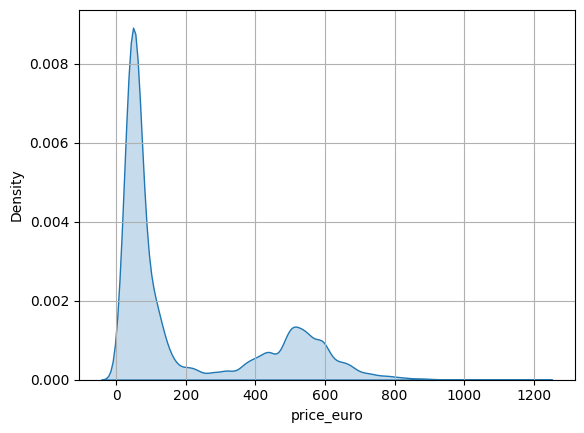

In [50]:
sns.kdeplot(data=df, x="price_euro",fill=True)
plt.grid()

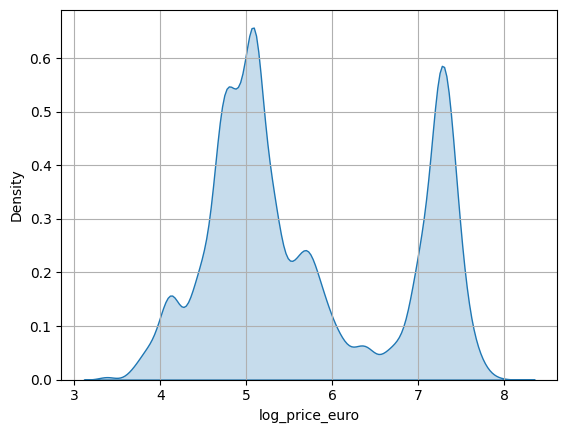

In [51]:
sns.kdeplot(data=df, x="log_price_euro",fill=True)
plt.grid()

In [30]:
for value in df.select_dtypes(include=['object']).columns : 
    print(f"======{value}======")
    print(df[f"{value}"].value_counts())

======airline======
airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64
======flight======
flight
UK-706     3235
UK-772     2741
UK-720     2650
UK-836     2542
UK-822     2468
           ... 
6E-2914       1
G8-107        1
SG-9974       1
6E-865        1
SG-8339       1
Name: count, Length: 1561, dtype: int64
======source_city======
source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64
======departure_time======
departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64
======stops======
stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64
======arrival_time======
arrival_time
Night            91538
Evening          78323
Mo

# Preprocessing

In [31]:
df.drop("Unnamed: 0",
        axis=1,
        inplace = True)

**On va faire du binaire pour les variables catégorielles a 2 modalités**

In [32]:
df["class"] = df["class"].replace({"Business" : 1,
                                   "Economy" : 0})

C:\Users\jbche\AppData\Local\Temp\ipykernel_18452\4171413487.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["class"] = df["class"].replace({"Business" : 1,


**On va faire du Ordinal encoding pour les variables caétgorielles qui ont une hierachie**

In [33]:
df["stops"] = df["stops"].replace({
    "zero": 0,
    "one": 1,
    "two_or_more": 2
})

C:\Users\jbche\AppData\Local\Temp\ipykernel_18452\2358550755.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["stops"] = df["stops"].replace({


**On va faire du One Hot encoding pour les variables caétgorielles sans hiearchie**

In [34]:
def one_hot_encoding(colonnes: list[str], dataframe: pd.DataFrame) -> pd.DataFrame:
    df = dataframe.copy()
    for col in colonnes:
        dummies = pd.get_dummies(df[col], prefix=col,dtype=int)
        df = df.drop(columns=[col])       
        df = df.join(dummies)  
    return df

df = one_hot_encoding(["airline","source_city","arrival_time","destination_city","departure_time"],df)


In [35]:
df.head()

,flight,stops,class,duration,days_left,price,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,...,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,departure_time_Afternoon,departure_time_Early_Morning,departure_time_Evening,departure_time_Late_Night,departure_time_Morning,departure_time_Night
0,SG-8709,0,0,2.17,1,5953,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
1,SG-8157,0,0,2.33,1,5953,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
2,I5-764,0,0,2.17,1,5956,1,0,0,0,...,0,0,0,1,0,1,0,0,0,0
3,UK-995,0,0,2.25,1,5955,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
4,UK-963,0,0,2.33,1,5955,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0


# Modélisation

In [36]:
X = df.drop("price",axis=1)
Y = df["price"]